Wczytywanie danych...
Rozpoczynam pętlę Walk-Forward. Łączna liczba kroków: 10

>>> KROK 1/10 | Rebalancing w dacie: 2017-01-02


2026/06/18 19:51:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Wybrane spółki na następny okres: ['WFC', 'ORCL', 'NKE']

>>> KROK 2/10 | Rebalancing w dacie: 2017-02-01


2026/06/18 19:51:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Wybrane spółki na następny okres: ['NVDA', 'MRK', 'WFC']

>>> KROK 3/10 | Rebalancing w dacie: 2017-03-03


...

Wybrane spółki na następny okres: ['TSLA', 'AMZN', 'GS']

>>> KROK 9/10 | Rebalancing w dacie: 2017-09-05


2026/06/18 19:52:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Wybrane spółki na następny okres: ['NVDA', 'MS', 'NKE']

>>> KROK 10/10 | Rebalancing w dacie: 2017-10-05


2026/06/18 19:52:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Wybrane spółki na następny okres: ['TSLA', 'NVDA', 'ORCL']


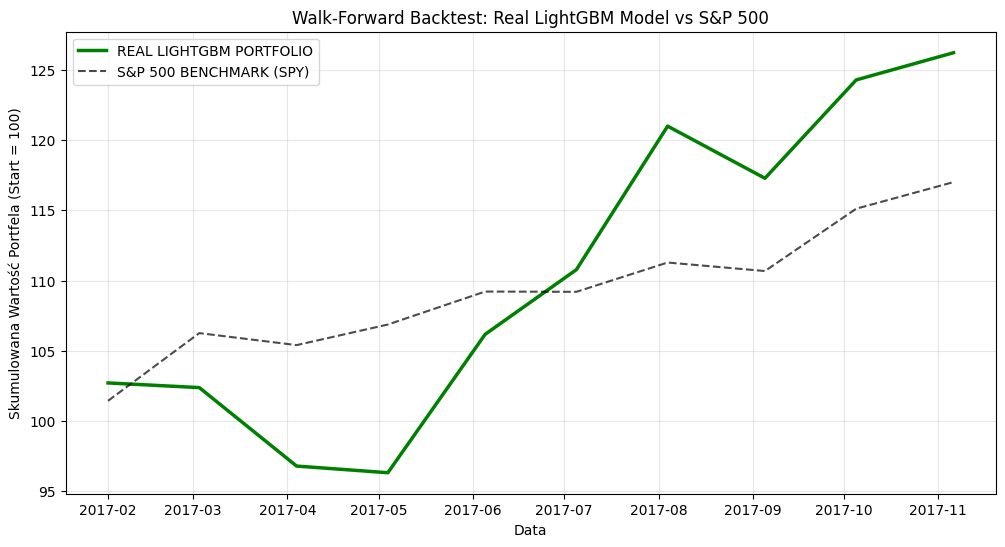

Końcowy wynik Portfela: 126.21
Końcowy wynik S&P 500: 117.00
Wygenerowana Alfa strategii: 9.21 punktów procentowych.


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import mlflow
import mlflow.lightgbm
import warnings

warnings.filterwarnings("ignore")

# --- USTAWIANIE EKSPERYMENTU MLFLOW ---
mlflow.set_experiment("SP500_Walk_Forward_Strategy")

# --- KONFIGURACJA ŚCIEŻEK (Zgodnie z Twoim środowiskiem) ---
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# --- 1. PRZYGOTOWANIE BAZOWYCH DANYCH ---
def load_all_data():
    """Wczytuje ceny zamknięcia i wylicza logarytmiczne stopy zwrotu dla SPY i Akcji"""
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    spy['SPY_Ret'] = np.log(spy['Close'] / spy['Close'].shift(1))
    
    stock_dfs = {}
    for ticker in sector_map.keys():
        f_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(f_path):
            df = pd.read_csv(f_path, index_col='Date', parse_dates=True).sort_index()
            df['Ret'] = np.log(df['Close'] / df['Close'].shift(1))
            stock_dfs[ticker] = df
            
    return spy, stock_dfs

print("Wczytywanie danych...")
df_spy, df_stocks = load_all_data()

# --- 2. GENEROWANIE CECH (FEATURE ENGINEERING) ---
def extract_features_for_date(date_point, horizon=22):
    """
    Dla podanej daty wyciąga cechy (X) oraz target (y) dla wszystkich dostępnych akcji.
    Target: Nadwyżkowa stopa zwrotu (Alpha) akcji względem SPY przez najbliższe 'horizon' dni.
    """
    features_list = []
    
    # Wycinamy historię SPY do danego momentu
    spy_cut = df_spy.loc[:date_point]
    if len(spy_cut) < 60: return None
    
    # Przyszłość SPY do wyliczenia targetu
    spy_future = df_spy.loc[date_point:].iloc[1:horizon+1]
    if len(spy_future) < horizon: return None
    spy_future_ret = np.log(spy_future['Close'].iloc[-1] / spy_cut['Close'].iloc[-1])
    
    for ticker, df in df_stocks.items():
        df_cut = df.loc[:date_point]
        df_future = df.loc[date_point:].iloc[1:horizon+1]
        
        if len(df_cut) < 60 or len(df_future) < horizon:
            continue
            
        rets_20 = df_cut['Ret'].tail(20).dropna()
        rets_60 = df_cut['Ret'].tail(60).dropna()
        
        # Cechy z ARIMA
        try:
            m_arima = ARIMA(rets_20, order=(1, 0, 1)).fit()
            pred_arima = m_arima.forecast(steps=1).values[0]
        except:
            pred_arima = 0.0
            
        # Cechy z GARCH
        try:
            m_garch = arch_model(rets_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
            pred_vol = np.sqrt(m_garch.forecast(horizon=1).variance.values[-1][0])
        except:
            pred_vol = rets_60.std()
            
        # Dodatkowe klasyczne wskaźniki jako cechy
        momentum_20 = np.log(df_cut['Close'].iloc[-1] / df_cut['Close'].iloc[-20])
        volatility_20 = rets_20.std()
        
        # TARGET (y): Faktyczna Alpha wygenerowana w przyszłości
        stock_future_ret = np.log(df_future['Close'].iloc[-1] / df_cut['Close'].iloc[-1])
        future_alpha = stock_future_ret - spy_future_ret
        
        features_list.append({
            'Date': date_point,
            'Ticker': ticker,
            'feat_arima': pred_arima,
            'feat_garch': pred_vol,
            'feat_momentum': momentum_20,
            'feat_volatility': volatility_20,
            'target_alpha': future_alpha
        })
        
    return pd.DataFrame(features_list) if features_list else None

# --- 3. GŁÓWNA PĘTLA WALK-FORWARD VALIDATION (BACKTEST DYNAMICZNY) ---
# Definiujemy punkty rebalancingu portfela (np. co 22 dni handlowe od roku 2015)
trading_days = df_spy.loc['2017-01-01':].index
rebalance_dates = [trading_days[i] for i in range(0, len(trading_days), 22)]

portfolio_returns_old = []
spy_returns = []
test_dates_executed = []

print(f"Rozpoczynam pętlę Walk-Forward. Łączna liczba kroków: {len(rebalance_dates)-1}")

for step in range(len(rebalance_dates) - 1):
    current_date = rebalance_dates[step]
    next_date = rebalance_dates[step + 1]
    
    print(f"\n>>> KROK {step+1}/{len(rebalance_dates)-1} | Rebalancing w dacie: {current_date.strftime('%Y-%m-%d')}")
    
    # A. Zbieranie historycznych danych treningowych (Wszystko od początku do 'current_date' z krokiem wstecz)
    # Dla optymalizacji bierzemy losowe 20 dat historycznych jako reprezentację treningu z przeszłości
    hist_dates = df_spy.loc[:current_date].index[-300::22] 
    
    train_data_list = []
    for d in hist_dates:
        df_feats = extract_features_for_date(d)
        if df_feats is not None:
            train_data_list.append(df_feats)
            
    if not train_data_list:
        continue
        
    df_train = pd.concat(train_data_list, ignore_index=True)
    
    X_train = df_train[['feat_arima', 'feat_garch', 'feat_momentum', 'feat_volatility']]
    y_train = df_train['target_alpha']
    
    # B. Trening modelu LightGBM i logowanie do MLflow
    with mlflow.start_run(nested=True):
        mlflow.log_param("step", step)
        mlflow.log_param("train_date_end", current_date.strftime('%Y-%m-%d'))
        
        train_dataset = lgb.Dataset(X_train, label=y_train)
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'learning_rate': 0.05,
            'max_depth': 4,
            'verbose': -1
        }
        
        # Trenowanie
        model = lgb.train(params, train_dataset, num_boost_round=50)
        
        # Wyliczenie błędu na zbiorze treningowym
        preds_train = model.predict(X_train)
        rmse_train = np.sqrt(np.mean((y_train - preds_train) ** 2))
        mlflow.log_metric("train_rmse", rmse_train)
        mlflow.lightgbm.log_model(model, f"model_step_{step}")
    
    # C. INFERENCJA (Prognoza na kolejny okres)
    df_current_test = extract_features_for_date(current_date)
    if df_current_test.empty or df_current_test is None:
        continue
        
    X_test = df_current_test[['feat_arima', 'feat_garch', 'feat_momentum', 'feat_volatility']]
    
    # model.predict() - Użycie prawdziwego modelu!
    df_current_test['pred_alpha'] = model.predict(X_test)
    
    # Selekcja TOP 3 spółek z najwyższą prognozowaną nadwyżką (alfą)
    top_picks = df_current_test.sort_values(by='pred_alpha', ascending=False).head(3)
    selected_tickers = top_picks['Ticker'].tolist()
    print(f"Wybrane spółki na następny okres: {selected_tickers}")
    
    # D. OBLICZANIE STÓP ZWROTU W NASTĘPNYM OKRESIE (Do kolejnego rebalancingu)
    # Wynik SP500 (Benchmark)
    spy_period = df_spy.loc[current_date:next_date]
    spy_ret_period = (spy_period['Close'].iloc[-1] / spy_period['Close'].iloc[0]) - 1
    spy_returns.append(spy_ret_period)
    
    # Wynik wybranego Portfela (Równe wagi: po 33% na każdą z 3 spółek)
    # Tutaj w kolejnym kroku wejdzie Twój drugi model "Efficient Frontier" nadający dynamiczne wagi!
    stock_rets_period = []
    for ticker in selected_tickers:
        s_df = df_stocks[ticker].loc[current_date:next_date]
        s_ret = (s_df['Close'].iloc[-1] / s_df['Close'].iloc[0]) - 1
        stock_rets_period.append(s_ret)
        
    portfolio_ret_period = np.mean(stock_rets_period)
    portfolio_returns_old.append(portfolio_ret_period)
    
    test_dates_executed.append(next_date)

# --- 4. summary and visualization ---
cum_portfolio_old = np.cumprod(1 + np.array(portfolio_returns_old)) * 100
cum_spy = np.cumprod(1 + np.array(spy_returns)) * 100

plt.figure(figsize=(12, 6))
plt.plot(test_dates_executed, cum_portfolio_old, color='green', lw=2.5, label='REAL LIGHTGBM PORTFOLIO')
plt.plot(test_dates_executed, cum_spy, color='black', ls='--', alpha=0.7, label='S&P 500 BENCHMARK (SPY)')
plt.title('Walk-Forward Backtest: Real LightGBM Model vs S&P 500')
plt.xlabel('Data')
plt.ylabel('Skumulowana Wartość Portfela (Start = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_alpha = (cum_portfolio_old[-1] - 100) - (cum_spy[-1] - 100)
print(f"Końcowy wynik Portfela: {cum_portfolio_old[-1]:.2f}")
print(f"Końcowy wynik S&P 500: {cum_spy[-1]:.2f}")
print(f"Wygenerowana Alfa strategii: {final_alpha:.2f} punktów procentowych.")

## new model

In [ ]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
import warnings

warnings.filterwarnings("ignore")

mlflow.set_experiment("SP500_Walk_Forward_Classification")

# paths
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

# sector mapping
sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}


In [2]:
def load_all_data():
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    spy['SPY_Ret'] = np.log(spy['Close'] / spy['Close'].shift(1))

    stock_dfs = {}
    for ticker in sector_map.keys():
        f_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(f_path):
            df = pd.read_csv(f_path, index_col='Date', parse_dates=True).sort_index()
            df['Ret'] = np.log(df['Close'] / df['Close'].shift(1))
            stock_dfs[ticker] = df

    return spy, stock_dfs

df_spy, df_stocks = load_all_data()


In [3]:
def extract_features_for_date(date_point, horizon=22):
    features = []

    spy_cut = df_spy.loc[:date_point]
    if len(spy_cut) < 120:
        return None

    spy_future = df_spy.loc[date_point:].iloc[1:horizon+1]
    if len(spy_future) < horizon:
        return None

    spy_future_ret = np.log(spy_future['Close'].iloc[-1] / spy_cut['Close'].iloc[-1])
    spy_rets = spy_cut['SPY_Ret'].dropna()

    if len(spy_rets) < 60:
        return None

    spy_mom_20 = spy_rets.tail(20).sum()
    spy_mom_60 = spy_rets.tail(60).sum()

    for ticker, df in df_stocks.items():
        df_cut = df.loc[:date_point]
        df_future = df.loc[date_point:].iloc[1:horizon+1]

        if len(df_cut) < 120 or len(df_future) < horizon:
            continue

        rets = df_cut['Ret'].dropna()
        if len(rets) < 60:
            continue

        # Momentum
        mom_5 = rets.tail(5).sum()
        mom_10 = rets.tail(10).sum()
        mom_20 = rets.tail(20).sum()
        mom_60 = rets.tail(60).sum()

        # Volatility
        vol_20 = rets.tail(20).std()
        vol_60 = rets.tail(60).std()

        # Relative to SPY
        rel_mom_20_spy = mom_20 - spy_mom_20
        rel_mom_60_spy = mom_60 - spy_mom_60

        # Relative to sector
        sector_ticker = sector_map.get(ticker, None)
        sec_mom_20 = np.nan
        sec_mom_60 = np.nan

        if sector_ticker:
            sec_path = os.path.join(etf_path, f"{sector_ticker.lower()}_clean.csv")
            if os.path.exists(sec_path):
                df_sec = pd.read_csv(sec_path, index_col='Date', parse_dates=True).sort_index()
                df_sec['Ret'] = np.log(df_sec['Close'] / df_sec['Close'].shift(1))
                sec_rets = df_sec.loc[:date_point]['Ret'].dropna()
                if len(sec_rets) >= 60:
                    sec_mom_20 = sec_rets.tail(20).sum()
                    sec_mom_60 = sec_rets.tail(60).sum()

        rel_mom_20_sector = mom_20 - sec_mom_20 if not np.isnan(sec_mom_20) else np.nan
        rel_mom_60_sector = mom_60 - sec_mom_60 if not np.isnan(sec_mom_60) else np.nan

        # Volume
        vol_series = df_cut['Volume'].dropna()
        if len(vol_series) < 60:
            continue

        vol_mean_20 = vol_series.tail(20).mean()
        vol_mean_60 = vol_series.tail(60).mean()
        vol_last = vol_series.iloc[-1]

        vol_rel_20 = vol_last / vol_mean_20 if vol_mean_20 > 0 else 1.0
        vol_rel_60 = vol_last / vol_mean_60 if vol_mean_60 > 0 else 1.0

        # Calendar
        d = pd.Timestamp(date_point)
        day_of_week = d.weekday()
        month = d.month
        is_month_end = int(d.is_month_end)
        is_quarter_end = int(d.is_quarter_end)

        # Target
        stock_future_ret = np.log(df_future['Close'].iloc[-1] / df_cut['Close'].iloc[-1])
        target = int(stock_future_ret > spy_future_ret)

        features.append({
            'Date': date_point,
            'Ticker': ticker,
            'mom_5': mom_5,
            'mom_10': mom_10,
            'mom_20': mom_20,
            'mom_60': mom_60,
            'vol_20': vol_20,
            'vol_60': vol_60,
            'rel_mom_20_spy': rel_mom_20_spy,
            'rel_mom_60_spy': rel_mom_60_spy,
            'rel_mom_20_sector': rel_mom_20_sector,
            'rel_mom_60_sector': rel_mom_60_sector,
            'vol_rel_20': vol_rel_20,
            'vol_rel_60': vol_rel_60,
            'day_of_week': day_of_week,
            'month': month,
            'is_month_end': is_month_end,
            'is_quarter_end': is_quarter_end,
            'target': target
        })

    return pd.DataFrame(features) if features else None


In [ ]:
feature_cols = [
    'mom_5', 'mom_10', 'mom_20', 'mom_60',
    'vol_20', 'vol_60',
    'rel_mom_20_spy', 'rel_mom_60_spy',
    'rel_mom_20_sector', 'rel_mom_60_sector',
    'vol_rel_20', 'vol_rel_60',
    'day_of_week', 'month', 'is_month_end', 'is_quarter_end'
]

trading_days_new = df_spy.loc['2017-01-01':].index
rebalance_dates = [trading_days_new[i] for i in range(0, len(trading_days_new), 22)]

portfolio_returns = []
spy_returns = []
test_dates = []

for step in range(len(rebalance_dates) - 1):
    current_date = rebalance_dates[step]
    next_date = rebalance_dates[step + 1]

    # ZTraining set: last 300 days every 22 days
    hist_dates = df_spy.loc[:current_date].index[-300::22]

    train_data = []
    for d in hist_dates:
        df_feat = extract_features_for_date(d)
        if df_feat is not None:
            train_data.append(df_feat)

    if not train_data:
        continue

    df_train = pd.concat(train_data, ignore_index=True)

    X_train = df_train[feature_cols]
    y_train = df_train['target']

    with mlflow.start_run(nested=True):
        train_dataset = lgb.Dataset(X_train, label=y_train)

        params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'learning_rate': 0.05,
            'max_depth': 4,
            'verbose': -1
        }

        model = lgb.train(params, train_dataset, num_boost_round=80)

    # Test
    df_test = extract_features_for_date(current_date)
    if df_test is None or df_test.empty:
        continue

    X_test = df_test[feature_cols]
    df_test['prob'] = model.predict(X_test)

    top3 = df_test.sort_values(by='prob', ascending=False).head(3)
    tickers = top3['Ticker'].tolist()

    print(f"{current_date.date()} → {tickers}")

    # Returns
    spy_period = df_spy.loc[current_date:next_date]
    spy_ret = (spy_period['Close'].iloc[-1] / spy_period['Close'].iloc[0]) - 1
    spy_returns.append(spy_ret)

    stock_rets = []
    for t in tickers:
        s_df = df_stocks[t].loc[current_date:next_date]
        s_ret = (s_df['Close'].iloc[-1] / s_df['Close'].iloc[0]) - 1
        stock_rets.append(s_ret)

    portfolio_returns.append(np.mean(stock_rets))
    test_dates.append(next_date)


2017-01-02 → ['ORCL', 'AMZN', 'MSFT']
2017-02-01 → ['WFC', 'AAPL', 'NVDA']
2017-03-03 → ['JNJ', 'NVDA', 'AAPL']
2017-04-04 → ['GS', 'PEP', 'WFC']
2017-05-04 → ['MRK', 'AAPL', 'GS']
2017-06-05 → ['TSLA', 'BAC', 'WFC']
2017-07-05 → ['NVDA', 'TSLA', 'GOOGL']
2017-08-04 → ['WFC', 'BAC', 'NVDA']
2017-09-05 → ['TSLA', 'NVDA', 'MSFT']
2017-10-05 → ['ABBV', 'MRK', 'NVDA']


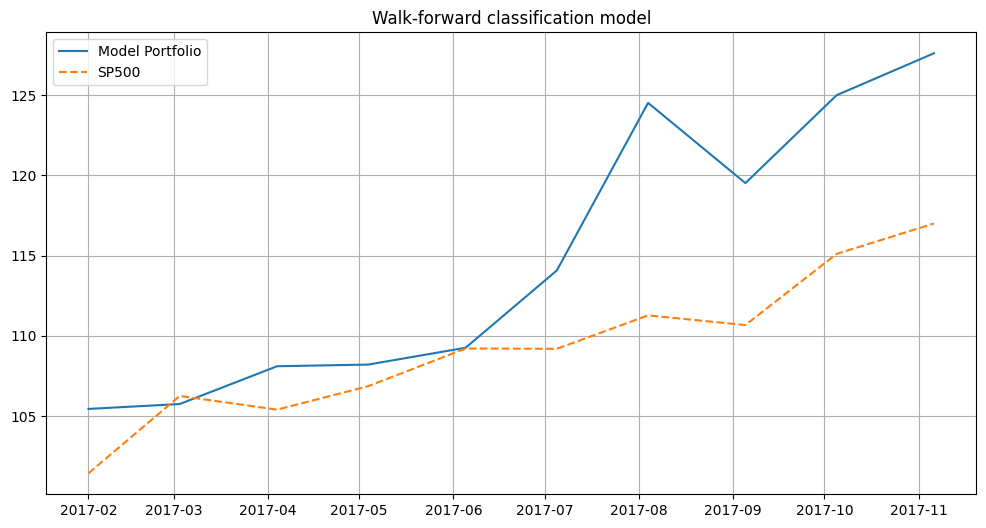

In [5]:
cum_portfolio_new = np.cumprod(1 + np.array(portfolio_returns)) * 100
cum_spy = np.cumprod(1 + np.array(spy_returns)) * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_dates, cum_portfolio_new, label="Model Portfolio")
plt.plot(test_dates, cum_spy, label="SP500", linestyle='--')
plt.legend()
plt.grid(True)
plt.title("Walk-forward classification model")
plt.show()


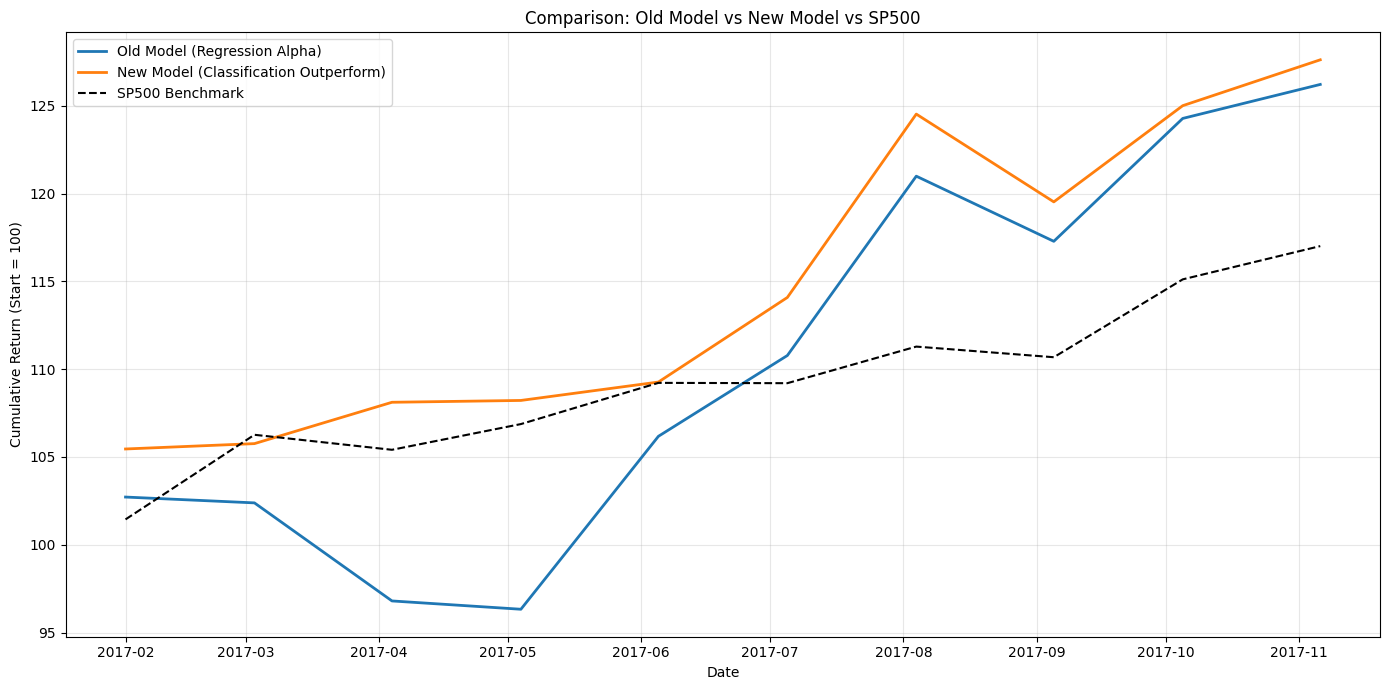

In [ ]:
plt.figure(figsize=(14, 7))

# old model
plt.plot(test_dates, cum_portfolio_old, label="Old Model (Regression Alpha)", linewidth=2)

# new model
plt.plot(test_dates, cum_portfolio_new, label="New Model (Classification Outperform)", linewidth=2)

# SP500
plt.plot(test_dates, cum_spy, label="SP500 Benchmark", linestyle='--', color='black')

plt.title("Comparison: Old Model vs New Model vs SP500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Start = 100)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
